In [1]:
from datetime import date
import pandas as pd
import os
import glob
import pycytominer
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2 

In [2]:
# load custom collection of functions
import sys
sys.path.append('/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/')
import utility_functions as UTIL

In [3]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

compound_path = parent_directory + 'compound_analysis/'

input_path = parent_directory + "results/"
output_path =  parent_directory + "revision_results/"

figure_path = parent_directory + "revision_figures/"

In [4]:
HepG2_nocodazole_cluster = pd.read_csv(compound_path + 'HepG2_nocodazole_cluster.csv')
HepG2_nocodazole_cluster.shape

(18, 20)

In [5]:
file_HepG2_Median_type = '/*[0-9]_' + 'FMP_HepG2_norm_reduced_Median_Cell-Number.csv'
files_HepG2_Median = glob.glob(input_path + file_HepG2_Median_type)

### gets latest file
max_file_HepG2_Median = max(files_HepG2_Median, key=os.path.getctime)

### load file
data_HepG2_Median = pd.read_csv(max_file_HepG2_Median)
data_HepG2_Median.shape

(2480, 659)

In [6]:
data_HepG2_Median.head()

,Metadata_EOS,Metadata_Plate,Metadata_Concentration,Metadata_Partner,Metadata_Object_Count,Nuc_AreaShape_BoundingBoxMaximum_Y,Nuc_AreaShape_Compactness,Nuc_AreaShape_Eccentricity,Nuc_AreaShape_Extent,Nuc_AreaShape_MaxFeretDiameter,...,Cyto_Texture_InverseDifferenceMoment_ER_5_03_256,Cyto_Texture_SumAverage_AGP_10_02_256,Cyto_Texture_SumAverage_DNA_10_01_256,Cyto_Texture_SumAverage_DNA_10_02_256,Cyto_Texture_SumAverage_DNA_3_01_256,Cyto_Texture_SumEntropy_DNA_10_03_256,Cyto_Texture_SumEntropy_ER_3_00_256,Cyto_Texture_SumVariance_DNA_10_00_256,Cyto_Texture_SumVariance_DNA_3_03_256,Cyto_Texture_SumVariance_DNA_5_01_256
0,DMSO,B1001,0,Bioactives,925.5,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,-2.796374e-15,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.449795e-15
1,DMSO,B1002,0,Bioactives,929.0,0.0,0.0,0.0,0.0,0.0,...,-2.399990e-15,0.000000e+00,0.0,0.000000e+00,0.000000e+00,-1.524999e-14,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,DMSO,B1003,0,Bioactives,895.5,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.0,2.199629e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.949965e-15,0.000000e+00
3,DMSO,B1004,0,Bioactives,914.5,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,DMSO,B1005,0,Bioactives,937.0,0.0,0.0,0.0,0.0,0.0,...,-2.399990e-15,0.000000e+00,0.0,0.000000e+00,6.300516e-15,3.700165e-15,5.999975e-15,-1.250085e-15,0.000000e+00,-1.196959e-15


# Remove non-reproducible compounds

In [7]:
# data_HepG2_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_HepG2_norm.csv")
file_HepG2_nonreplicating_type = '/*[0-9]_' + 'FMP_HepG2_non-replicating.csv'
files_HepG2_nonreplicating = glob.glob(input_path + file_HepG2_nonreplicating_type)

### gets latest file
max_files_HepG2_nonreplicating = max(files_HepG2_nonreplicating, key=os.path.getctime)

### load file
data_HepG2_nonreplicating = pd.read_csv(max_files_HepG2_nonreplicating)
data_HepG2_nonreplicating.shape

(72, 1)

In [8]:
data_HepG2_Median = data_HepG2_Median.loc[~data_HepG2_Median["Metadata_EOS"].isin(data_HepG2_nonreplicating["Metadata_EOS"])].copy()
data_HepG2_Median.shape

(2408, 659)

# Remove non-active compounds

In [9]:
file_HepG2_inactive_type = '/*[0-9]_' + 'FMP_HepG2_low-active.csv'
files_HepG2_inactive = glob.glob(input_path + file_HepG2_inactive_type)

### gets latest file
max_file_HepG2_inactive = max(files_HepG2_inactive, key=os.path.getctime)

### load file
data_HepG2_inactive = pd.read_csv(max_file_HepG2_inactive)
data_HepG2_inactive.shape

(1503, 1)

In [10]:
data_HepG2_Median = data_HepG2_Median.loc[~data_HepG2_Median["Metadata_EOS"].isin(data_HepG2_inactive["Metadata_EOS"])].copy()
data_HepG2_Median.shape

(899, 659)

# Test against nocodazole and tetrandrine

In [11]:
features = UTIL.get_feature_vector(data_HepG2_Median)
nocodazole_median_feature_vector = data_HepG2_Median[data_HepG2_Median['Metadata_EOS'] == 'Nocodazole'][features].median().to_numpy()
tetrandrine_median_feature_vector = data_HepG2_Median[data_HepG2_Median['Metadata_EOS'] == 'Tetrandrine'][features].median().to_numpy()

In [12]:
import numpy as np
from scipy.stats import pearsonr, spearmanr, kendalltau

corr = []

for compound in HepG2_nocodazole_cluster['Metadata_EOS']:

    if compound != 'Nocodazole':

        compound_feature_vector = data_HepG2_Median[data_HepG2_Median['Metadata_EOS'] == compound][features].iloc[0, :].to_numpy()

        corr_noco, p_value_noco = pearsonr(nocodazole_median_feature_vector, compound_feature_vector)
        print(f"{compound} vs Nocodazole: {corr_noco}, p-value: {p_value_noco}")

        corr_tet, p_value_tet = pearsonr(tetrandrine_median_feature_vector, compound_feature_vector)
        print(f"{compound} vs Tetrandrine: {corr_tet}, p-value: {p_value_tet}")


        corr.append({'Compound': compound,
                           'Corr_Nocodazole': corr_noco,
                           'P_Nocodazoleg':p_value_noco,
                           'Corr_Tetrandrine':corr_tet,
                           'P_Tetrandrine':p_value_tet})
        
corr_df = pd.DataFrame(corr)

EOS100001 vs Nocodazole: 0.9148316936503802, p-value: 6.00328209108875e-259
EOS100001 vs Tetrandrine: 0.1808882501404159, p-value: 3.231321866549674e-06
EOS100234 vs Nocodazole: 0.9513670499261748, p-value: 0.0
EOS100234 vs Tetrandrine: 0.14998135941208793, p-value: 0.00011811932039315086
EOS100406 vs Nocodazole: 0.8502863378384109, p-value: 6.606219793595514e-184
EOS100406 vs Tetrandrine: 0.30543588467540395, p-value: 1.3741380065872667e-15
EOS100492 vs Nocodazole: 0.9439393274363558, p-value: 4.9293952e-316
EOS100492 vs Tetrandrine: 0.23091920019899606, p-value: 2.3003925791072236e-09
EOS100806 vs Nocodazole: 0.8439739279018812, p-value: 1.5359926398713962e-178
EOS100806 vs Tetrandrine: 0.218655339066519, p-value: 1.608491267034385e-08
EOS100861 vs Nocodazole: 0.9575636896561535, p-value: 0.0
EOS100861 vs Tetrandrine: 0.16615510612280426, p-value: 1.948191371225629e-05
EOS100922 vs Nocodazole: 0.8929577297978182, p-value: 3.362175577331633e-228
EOS100922 vs Tetrandrine: 0.26364443712

In [13]:
def null_corr(df, n_samples, metadata_compound_name):
    """
        Null distribution between random "replicates".
        Parameters:
        ------------
        df: pandas.DataFrame
        n_samples: int
        n_replicates: int
        metadata_compound_name: Compound name feature
        Returns:
        --------
        list-like of correlation values, with a  length of `n_samples`
    """


    null_corr = []
    while len(null_corr) < n_samples:
        
        compounds = random.choices([_ for _ in range(len(df))], k = n_replicates)
        sample = df.loc[compounds].copy()
        if len(sample[metadata_compound_name].unique()) == n_replicates:
            sample_features = sample.loc[:, get_feature_vector(sample)]
            corr = np.corrcoef(sample_features)
            np.fill_diagonal(corr, np.nan)
            null_corr.append(np.nanmedian(corr))  # median non-replicate correlation
    return null_corr

In [14]:
data_HepG2_Median.reset_index(drop=True, inplace=True)

sampled_df = data_HepG2_Median.sample(n=10000, random_state=42, replace=True)

null_corr = []

for compound in sampled_df['Metadata_EOS']:

    if compound != 'Nocodazole':

        compound_feature_vector = sampled_df[sampled_df['Metadata_EOS'] == compound][features].iloc[0, :].to_numpy()

        corr_noco, p_value_noco = pearsonr(nocodazole_median_feature_vector, compound_feature_vector)

        null_corr.append({'Compound': compound,
                          'Corr_Nocodazole': corr_noco,
                          'P_Nocodazoleg':p_value_noco})
        
null_corr = pd.DataFrame(null_corr)
        

In [15]:
perc_95 = np.nanpercentile(null_corr['Corr_Nocodazole'], 95)
perc_95

0.7831172184277122

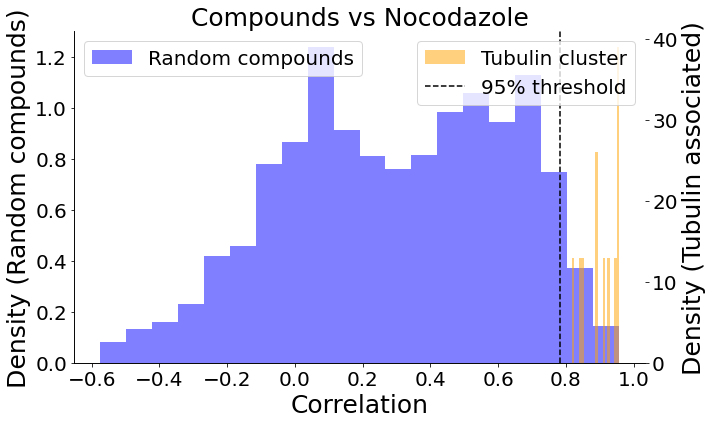

In [16]:
plt.figure(figsize=(10, 6))

# Create the first axis (left)
ax1 = plt.gca()

# Plot the first histogram (Random compounds)
ax1.hist(null_corr['Corr_Nocodazole'], label='Random compounds', density=True, bins=20, alpha=0.5, color='blue')
ax1.set_xlabel("Correlation", fontsize=25)
ax1.set_ylabel("Density (Random compounds)", fontsize=25)
ax1.tick_params(axis='both', labelsize=20)

# Create the second axis (right)
ax2 = ax1.twinx()

# Plot the second histogram (Tubulin associated with Nocodazole) on the second axis
ax2.hist(corr_df['Corr_Nocodazole'], label='Tubulin cluster', bins=20, alpha=0.5, color='orange', density=True)
ax2.set_ylabel("Density (Tubulin associated)", fontsize=25)
ax2.tick_params(axis='both', labelsize=20)

# Add vertical line for the 95% threshold
plt.axvline(perc_95, label='95% threshold', color='black', linestyle='--')

# Set the title and legend
plt.title("Compounds vs Nocodazole", fontsize=25)
ax1.legend(fontsize=20, loc='upper left')
ax2.legend(fontsize=20, loc='upper right')

# Adjust layout to prevent overlap
sns.despine()
plt.tight_layout()

plt.savefig(figure_path + os.sep + 'Noco_Corr_HepG2.pdf', dpi=300, bbox_inches='tight')


# Show plot
plt.show()

## HepG2 analysis against toxic compounds

In [17]:
# Perform against toxic compounds
# data_U2OS_Median = pd.read_csv(input_path + "2023-04-11_Bioactives_U2OS_norm_reduced_filtered_median.csv")
file_HepG2_tox_type = '/*[0-9]_' + 'FMP_HepG2_toxic_all.csv'
files_HepG2_tox = glob.glob(input_path + file_HepG2_tox_type)

### gets latest file
max_file_HepG2_tox = max(files_HepG2_tox, key=os.path.getctime)

### load file
data_HepG2_tox = pd.read_csv(max_file_HepG2_tox)
data_HepG2_tox.shape


(103, 1)

In [18]:
tox_compounds = data_HepG2_Median[data_HepG2_Median['Metadata_EOS'].isin(data_HepG2_tox['Metadata_EOS'])]
noco_cluster_compounds = data_HepG2_Median[data_HepG2_Median['Metadata_EOS'].isin(HepG2_nocodazole_cluster['Metadata_EOS'])]

In [19]:
noco_cluster_corr = []

for noco_compound in noco_cluster_compounds['Metadata_EOS']:

    noco_cluster_feature_vector =  noco_cluster_compounds[noco_cluster_compounds['Metadata_EOS'] == noco_compound][features].iloc[0, :].to_numpy()

    for tox_compound in tox_compounds['Metadata_EOS']:

        tox_compound_feature_vector = tox_compounds[tox_compounds['Metadata_EOS'] == tox_compound][features].iloc[0, :].to_numpy()    

        corr_noco, p_value_noco = pearsonr(tox_compound_feature_vector, noco_cluster_feature_vector)

        index = noco_compound + '_' + tox_compound

        noco_cluster_corr.append({'Compound': index,
                      'Corr_Nocodazole': corr_noco,
                      'P_Nocodazoleg':p_value_noco})

noco_cluster_corr = pd.DataFrame(noco_cluster_corr)

In [20]:
# Sample random compounds
data_HepG2_Median.reset_index(drop=True, inplace=True)
sampled_df = data_HepG2_Median.sample(n=10000, random_state=42, replace=True)

null_corr = []

for compound in sampled_df['Metadata_EOS']:
    
    compound_feature_vector = sampled_df[sampled_df['Metadata_EOS'] == compound][features].iloc[0, :].to_numpy()

    # randomly sample tox compounds
    tox_compound = tox_compounds.sample(n=1, random_state=42, replace=True).iloc[0]['Metadata_EOS']

    tox_compound_feature_vector = data_HepG2_Median[data_HepG2_Median['Metadata_EOS'] == tox_compound][features].iloc[0, :].to_numpy()

    corr_noco, p_value_noco = pearsonr(tox_compound_feature_vector, compound_feature_vector)

    null_corr.append({'Compound': compound,
                      'Corr_Nocodazole': corr_noco,
                      'P_Nocodazoleg':p_value_noco})
        
null_corr_tox = pd.DataFrame(null_corr)
        

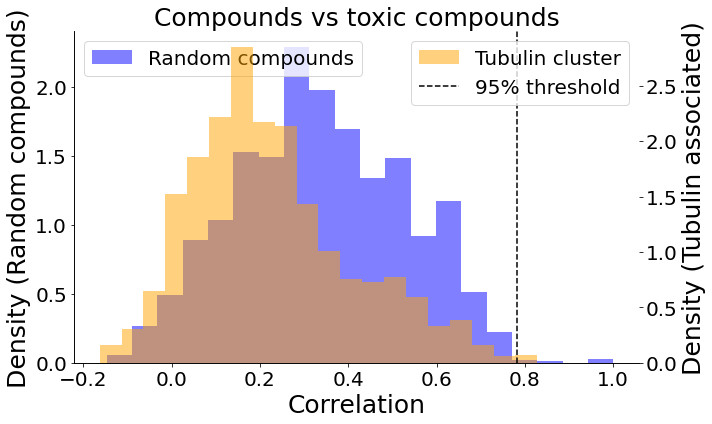

In [21]:
plt.figure(figsize=(10, 6))

# Create the first axis (left)
ax1 = plt.gca()

# Plot the first histogram (Random compounds)
ax1.hist(null_corr_tox['Corr_Nocodazole'], label='Random compounds', density=True, bins=20, alpha=0.5, color='blue')
ax1.set_xlabel("Correlation", fontsize=25)
ax1.set_ylabel("Density (Random compounds)", fontsize=25)
ax1.tick_params(axis='both', labelsize=20)

# Create the second axis (right)
ax2 = ax1.twinx()

# Plot the second histogram (Tubulin associated with Nocodazole) on the second axis
ax2.hist(noco_cluster_corr['Corr_Nocodazole'], label='Tubulin cluster', bins=20, alpha=0.5, color='orange', density=True)
ax2.set_ylabel("Density (Tubulin associated)", fontsize=25)
ax2.tick_params(axis='both', labelsize=20)

# Add vertical line for the 95% threshold
plt.axvline(perc_95, label='95% threshold', color='black', linestyle='--')

# Set the title and legend
plt.title("Compounds vs toxic compounds", fontsize=25)
ax1.legend(fontsize=20, loc='upper left')
ax2.legend(fontsize=20, loc='upper right')

# Adjust layout to prevent overlap
sns.despine()
plt.tight_layout()

plt.savefig(figure_path + os.sep + 'Toxic_Corr_HepG2.pdf', dpi=300, bbox_inches='tight')


# Show plot
plt.show()